<a href="https://colab.research.google.com/github/Perlangas28/Simulacion_1/blob/main/3erParcial_Equipo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tercer Examen Parcial


**Alumnas:** Perla Blancas Hernández, María de Jesús Nieto Delgadillo

**Materia:** Sistemas Financieros y Comerciales

**Indicaciones:**

Utilizando como activo subyacente la acción de una empresa de alta volatilidad, genere una proyección para el periodo comprendido del 17 de enero de 2026 al 17 de julio de 2026 (Es decir, debe de utilizar los datos comprendidos del 17 de junio 2024 al 17 de enero de 2026 para proyectar el precio al 17 de julio 2026) y genere lo
siguiente:

a. Una proyección de cual sería el valor de la acción para el 17 de julio de 2026 (1 pto)

b. Diseño de al menos tres estrategias con derivados considerando su proyección (0.75 ptos por cada una)

c. Generación de las gráficas correspondientes a dichas estrategias (0.5 ptos por gráfica)

d. Generación de las gráficas comparativas del desempeño de cada una de las estratregias y el desempeño de una inversión base (en caso de que considere una caída en los precios su escenario base debe ser un futuro corto, genérelo de forma sintética) (1.5 puntos)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Primero descargamos datos de Tesla


In [2]:
tesla = yf.download(
    "TSLA",
    start="2024-06-17",
    end="2026-01-17"
)

tesla.head()

/tmp/ipykernel_20795/3444274830.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2024-06-17,187.440002,188.809998,177.000000,177.919998,109786100
2024-06-18,184.860001,187.199997,182.369995,186.559998,68982300
2024-06-20,181.570007,185.210007,179.660004,184.679993,55893100
2024-06-21,183.009995,183.949997,180.690002,182.300003,61937300
2024-06-24,182.580002,188.800003,182.550003,184.970001,61992100


Calculamos rendimientos diarios

In [3]:
tesla["Rendimiento"] = tesla["Close"].pct_change()

tesla.head()

Price,Close,High,Low,Open,Volume,Rendimiento
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2024-06-17,187.440002,188.809998,177.000000,177.919998,109786100,NaN
2024-06-18,184.860001,187.199997,182.369995,186.559998,68982300,-0.013764
2024-06-20,181.570007,185.210007,179.660004,184.679993,55893100,-0.017797
2024-06-21,183.009995,183.949997,180.690002,182.300003,61937300,0.007931
2024-06-24,182.580002,188.800003,182.550003,184.970001,61992100,-0.002350


Calculamos rendimiento promedio

In [18]:
S_inicial = 187.44
S_final = 437.50

n = 400

mu = np.log(S_final/S_inicial)/n

print(mu)

print("Rendimiento promedio diario:")
print(mu)

0.0021190447789953223
Rendimiento promedio diario:
0.0021190447789953223


Obtenemos último precio

In [19]:
S0 = tesla["Close"].iloc[-1]

print("Precio actual:")
print(S0)

Precio actual:
Ticker
TSLA    437.5
Name: 2026-01-16 00:00:00, dtype: float64


Realizamos proyección al 17 de julio

In [22]:
T = 128

proyeccion = S0 * np.exp(mu*T)

print("Precio proyectado:")
print(round(proyeccion,2))

Precio proyectado:
Ticker
TSLA    573.82
Name: 2026-01-16 00:00:00, dtype: float64


Creamos rango de precios futuros

In [23]:
ST = np.arange(300,651,25)

ST

array([300, 325, 350, 375, 400, 425, 450, 475, 500, 525, 550, 575, 600,
       625, 650])

Ahora veamos cada una de las estrategias propuestas

Estrategia 1: Long Call

In [8]:
long_call = np.maximum(ST-450,0)-20

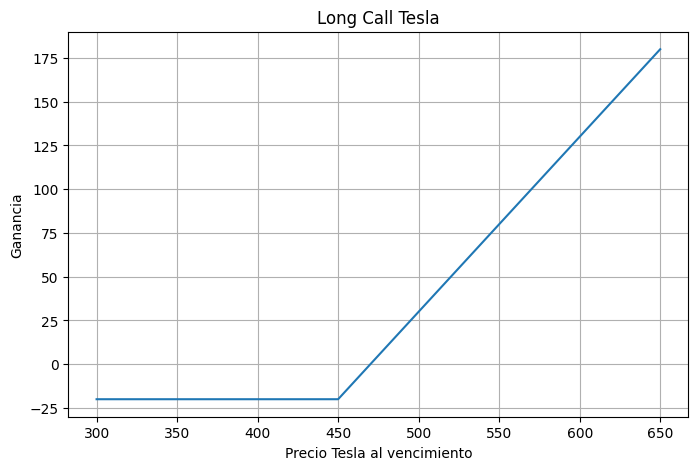

In [24]:
plt.figure(figsize=(8,5))
plt.plot(ST,long_call)
plt.title("Long Call Tesla")
plt.xlabel("Precio Tesla al vencimiento")
plt.ylabel("Ganancia")
plt.grid(True)
plt.show()

Estrategia 2: Bull Call Spread

In [25]:
bull_call = (
    np.maximum(ST-450,0)
    - np.maximum(ST-600,0)
    - 15
)

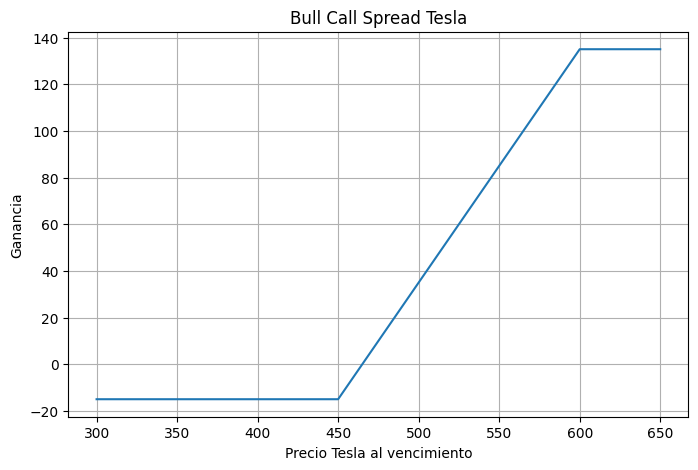

In [26]:
plt.figure(figsize=(8,5))
plt.plot(ST,bull_call)
plt.title("Bull Call Spread Tesla")
plt.xlabel("Precio Tesla al vencimiento")
plt.ylabel("Ganancia")
plt.grid(True)
plt.show()

Estrategia 3: Protective Put

In [27]:
protective_put = (
    (ST-437.5)
    + np.maximum(420-ST,0)
    - 12
)

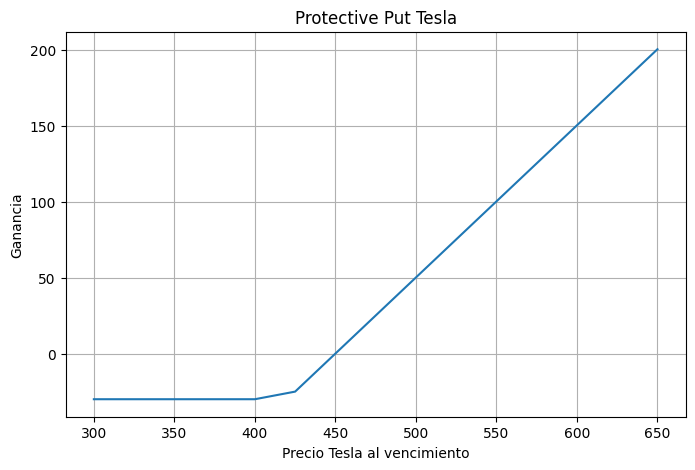

In [13]:
plt.figure(figsize=(8,5))
plt.plot(ST,protective_put)
plt.title("Protective Put Tesla")
plt.xlabel("Precio Tesla al vencimiento")
plt.ylabel("Ganancia")
plt.grid(True)
plt.show()

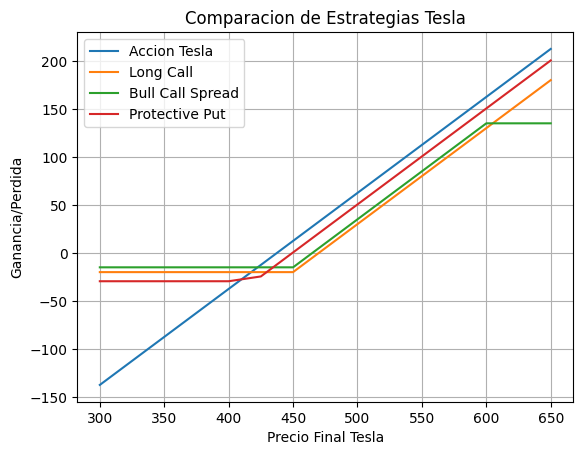

In [28]:
accion = ST - 437.5

plt.plot(ST,accion,label="Accion Tesla")
plt.plot(ST,long_call,label="Long Call")
plt.plot(ST,bull_call,label="Bull Call Spread")
plt.plot(ST,protective_put,label="Protective Put")

plt.title("Comparacion de Estrategias Tesla")
plt.xlabel("Precio Final Tesla")
plt.ylabel("Ganancia/Perdida")

plt.legend()
plt.grid(True)

plt.show()

Inversión base

In [29]:
resultado = pd.DataFrame({
    "ST":ST,
    "Accion":accion,
    "Long Call":long_call,
    "Bull Call Spread":bull_call,
    "Protective Put":protective_put
})

resultado

,ST,Accion,Long Call,Bull Call Spread,Protective Put
0,300,-137.5,-20,-15,-29.5
1,325,-112.5,-20,-15,-29.5
2,350,-87.5,-20,-15,-29.5
3,375,-62.5,-20,-15,-29.5
4,400,-37.5,-20,-15,-29.5
5,425,-12.5,-20,-15,-24.5
6,450,12.5,-20,-15,0.5
7,475,37.5,5,10,25.5
8,500,62.5,30,35,50.5
9,525,87.5,55,60,75.5


In [30]:
resultado.to_excel(
    "Estrategias_Tesla.xlsx",
    index=False
)

print("Archivo generado")

Archivo generado


Con base en los datos históricos de Tesla, se estimó un comportamiento alcista para el periodo analizado, obteniendo una proyección de aproximadamente 573.819 USD por acción para julio de 2026. A partir de esta proyección se diseñaron y evaluaron distintas estrategias con derivados financieros, observando que todas presentan resultados favorables bajo el escenario esperado.